<center>
  <img src="logo-ipb.png" width="300">
  <br>
  <h1>Relatório de Estimação de Irradiação Solar</h1>
</center>
<h3>Atividade 2: Estimação da Irradiação Solar Incidente num Módulo</h3>
<hr>
<b>Estudante:</b> Brendon (Londrina, PR, Brasil) | <b>Data de Aniversário:</b> 10 de Janeiro (n=10)
</center>

## Descrição do Problema
O objetivo deste trabalho é estimar a irradiação solar incidente num módulo fotovoltaico com inclinação de 35° e azimute de 0°, localizado em Londrina, PR, Brasil. Os cálculos seguem a metodologia de 13 etapas apresentada em aula.

In [ ]:
import pandas as pd
import numpy as np

# Configurações de Londrina e meu Aniversário
L = 11.857    # Latitude "PVGIS"  -23.328
n = 271          # 10 de Janeiro (Dia do ano n=10)
sigma = 12      # Inclinação do módulo
rho = 0.2       # Albedo (Refletividade do solo)
IH_mensal = 142.2 # Valor do seu CSV para Janeiro 147.6
IH = IH_mensal / 30 # Média diária (Etapa 5) /31
SC = 1.37       # Constante Solar (Etapa 4)

In [ ]:
#====================================#
#   Etapa 2: Cálculo da Declinação   #
#====================================#

delta = 23.45 * np.sin(np.radians((360/365) * (n - 81)))
print(f"Declinação Solar (delta): {delta:.2f} graus")

Declinação Solar (delta): -3.02 graus


In [ ]:
#====================================#
#      Etapa 3: Cálculo do H_SR      #
#====================================#

L_rad = np.radians(L)
delta_rad = np.radians(delta)

cos_HSR = -np.tan(L_rad) * np.tan(delta_rad)
H_SR_rad = np.arccos(cos_HSR)
H_SR_deg = np.degrees(H_SR_rad)

print(f"H_SR em graus: {H_SR_deg:.2f}°")
print(f"H_SR em radianos: {H_SR_rad:.3f} rad")

H_SR em graus: 89.37°
H_SR em radianos: 1.560 rad


In [ ]:
#========================================#
#   Etapa 4: Cálculo de I0 (kWh/m².day)  #
#========================================#

SC = 1.37  # Constante Solar [cite: 930]
termo_ajuste = 1 + 0.034 * np.cos(np.radians(360 * n / 365))
geometria_solar = (np.cos(L_rad) * np.cos(delta_rad) * np.sin(H_SR_rad)) + (H_SR_rad * np.sin(L_rad) * np.sin(delta_rad))

I0 = (24 / np.pi) * SC * termo_ajuste * geometria_solar
print(f"Irradiação Extraterrestre (I0): {I0:.2f} kWh/m².day")

Irradiação Extraterrestre (I0): 10.04 kWh/m².day


In [ ]:
#==============================================================#
#    Etapa 5: Razão entre o solo e o topo da atmosfera         #
#                    KT = IH / I0                              #
#==============================================================#

KT = IH / I0
print(f"Índice de Clareza (KT): {KT:.3f}")

Índice de Clareza (KT): 0.472


In [ ]:
#============================================================#
#      Etapa 6: Correlação de decomposição da insolação      #
#============================================================#

razao_difusa = 1.390 - 4.027*KT + 5.531*(KT**2) - 3.108*(KT**3)
IDH = razao_difusa * IH
print(f"Irradiação Difusa Horizontal (IDH): {IDH:.2f} kWh/m².day")

Irradiação Difusa Horizontal (IDH): 1.87 kWh/m².day


In [ ]:
#====================================#
#            Etapa 7: IDC            #
#====================================#

sigma_rad = np.radians(sigma)
IDC = IDH * (1 + np.cos(sigma_rad)) / 2 #[cite: 1154]
print(f"Irradiação Difusa no Coletor (IDC): {IDC:.2f} kWh/m².day")

Irradiação Difusa no Coletor (IDC): 1.85 kWh/m².day


In [ ]:
#====================================#
#            Etapa 8: IRC            #
#====================================#
IRC = rho * IH * (1 - np.cos(sigma_rad)) / 2 #[cite: 1155]
print(f"Irradiação Refletida no Coletor (IRC): {IRC:.2f} kWh/m².day")

Irradiação Refletida no Coletor (IRC): 0.01 kWh/m².day


In [ ]:
#========================================================#
#                Etapa 9: Definindo IBH                  #
#========================================================#
IBH = IH - IDH
print(f"Irradiação Direta Horizontal (IBH): {IBH:.2f} kWh/m².day")

Irradiação Direta Horizontal (IBH): 2.87 kWh/m².day


In [ ]:
#==============================================================#
#  Etapa 10: H_SRC (Ajuste para face Norte no Hemisfério Sul)  #
#==============================================================#
# Usei abs(L) e -delta para manter a lógica de "equator-facing" do slide

val_hsrc = -np.tan(np.radians(abs(L) - sigma)) * np.tan(-delta_rad)
H_SRC_rad = min(H_SR_rad, np.arccos(np.clip(val_hsrc, -1, 1)))
print(f"H_SRC em graus: {np.degrees(H_SRC_rad):.2f}°")

H_SRC em graus: 89.37°


In [ ]:
#====================================#
#           Etapa 11: RB             #
#====================================#
# Aplicando a fórmula com os valores em radianos

L_eff = np.radians(abs(L))
delta_eff = -delta_rad
S_eff = np.radians(sigma)

num = (np.cos(L_eff - S_eff) * np.cos(delta_eff) * np.sin(H_SRC_rad) +
       H_SRC_rad * np.sin(L_eff - S_eff) * np.sin(delta_eff))
den = (np.cos(L_eff) * np.cos(delta_eff) * np.sin(H_SR_rad) +
       H_SR_rad * np.sin(L_eff) * np.sin(delta_eff))

RB = num / den
print(f"Fator de Inclinação (RB): {RB:.3f}")

Fator de Inclinação (RB): 1.004


In [ ]:
#====================================#
#         Etapa 12: IBC              #
#====================================#

IBC = IBH * RB
print(f"Irradiação Direta no Coletor (IBC): {IBC:.2f} kWh/m².day")

Irradiação Direta no Coletor (IBC): 2.88 kWh/m².day


In [ ]:
#====================================#
#      Etapa 13: Resultado Final     #
#====================================#

IC = IBC + IDC + IRC
print(f"--- RESULTADO FINAL ---")
print(f"Irradiação Total no Módulo (IC): {IC:.2f} kWh/m².day")

--- RESULTADO FINAL ---
Irradiação Total no Módulo (IC): 4.74 kWh/m².day


In [ ]:
resumo_dados = {
    "Etapa": ["2", "3", "4", "5", "6", "11", "13"],
    "Variável": ["Declinação (δ)", "Ângulo Horário (H_SR)", "Extraterrestre (I0)", "Clareza (KT)", "Difusa (IDH)", "Fator RB", "Total Coletor (IC)"],
    "Valor": [f"{delta:.2f}°", f"{H_SR_deg:.2f}°", f"{I0:.2f}", f"{KT:.3f}", f"{IDH:.2f}", f"{RB:.3f}", f"{IC:.2f} kWh/m²"]
}

df_resumo = pd.DataFrame(resumo_dados)
display(df_resumo)

,Etapa,Variável,Valor
0,2,Declinação (δ),-3.02°
1,3,Ângulo Horário (H_SR),89.37°
2,4,Extraterrestre (I0),10.04
3,5,Clareza (KT),0.472
4,6,Difusa (IDH),1.87
5,11,Fator RB,1.004
6,13,Total Coletor (IC),4.74 kWh/m²


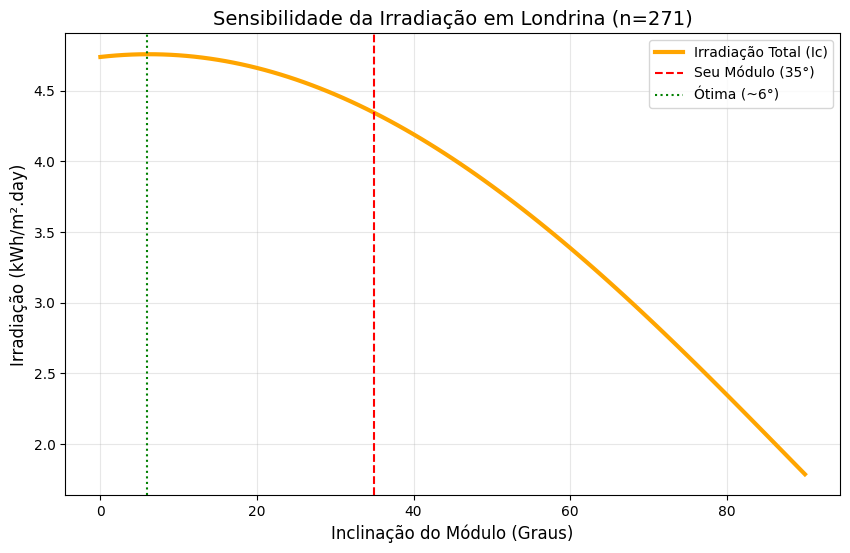

In [ ]:
import matplotlib.pyplot as plt

inclinacoes = np.arange(0, 91, 1)
resultados_ic = []

for s_teste in inclinacoes:
    s_rad_teste = np.radians(s_teste)

    idc_t = IDH * (1 + np.cos(s_rad_teste)) / 2
    irc_t = 0.2 * IH * (1 - np.cos(s_rad_teste)) / 2

    t_hsrc = -np.tan(np.radians(abs(L) - s_teste)) * np.tan(-delta_rad)
    h_src_t = min(H_SR_rad, np.arccos(np.clip(t_hsrc, -1, 1)))

    num_t = (np.cos(np.radians(abs(L) - s_teste)) * np.cos(-delta_rad) * np.sin(h_src_t) +
             h_src_t * np.sin(np.radians(abs(L) - s_teste)) * np.sin(-delta_rad))
    rb_t = num_t / den

    ibc_t = IBH * rb_t
    resultados_ic.append(ibc_t + idc_t + irc_t)

#====================================#
#             Plotagem               #
#====================================#
plt.figure(figsize=(10, 6))
plt.plot(inclinacoes, resultados_ic, color='orange', lw=3, label='Irradiação Total (Ic)')
plt.axvline(x=35, color='red', linestyle='--', label='Seu Módulo (35°)')
plt.axvline(x=inclinacoes[np.argmax(resultados_ic)], color='green', linestyle=':', label=f'Ótima (~{inclinacoes[np.argmax(resultados_ic)]}°)')

plt.title(f'Sensibilidade da Irradiação em Londrina (n={n})', fontsize=14)
plt.xlabel('Inclinação do Módulo (Graus)', fontsize=12)
plt.ylabel('Irradiação (kWh/m².day)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
#====================================#
#               MEMORIAL             #
#====================================#
memorial_texto = rf"""
# Memorial de Cálculo: Sistemas Fotovoltaicos
**Estudo de Caso:** Londrina, PR | **Data:** 10 de Janeiro ($n={n}$)

---

### **1. Geometria Solar e Irradiação Extraterrestre**
Nesta etapa, determinamos a declinação solar e a posição do sol para o dia do aniversário.

* **Declinação Solar ($\delta$):**
$$\delta = 23.45^\circ \sin\left[\frac{{360}}{{365}}({n}-81)\right] = \mathbf{{{delta:.2f}^\circ}}$$

* **Ângulo Horário do Nascer do Sol ($H_{{SR}}$):**
$$H_{{SR}} = \cos^{{-1}}(-\tan({L:.3f}^\circ) \cdot \tan({delta:.2f}^\circ)) = \mathbf{{{H_SR_deg:.2f}^\circ}}$$

* **Irradiação Extraterrestre Diária ($I_0$):**
$$I_0 = \frac{{24}}{{\pi}} \cdot 1.37 \cdot [1 + 0.034 \cos(\frac{{360 \cdot {n}}}{{365}})] \cdot (\dots) = \mathbf{{{I0:.2f} \text{{ kWh/m}}^2\cdot\text{{dia}}}}$$

---

### **2. Componentes da Radiação no Solo (Plano Horizontal)**
Com base nos dados extraídos do PVGIS ($I_H = {IH:.2f} \text{{ kWh/m}}^2$), decompomos a radiação:

* **Índice de Clareza ($K_T$):**
$$K_T = \frac{{{IH:.2f}}}{{{I0:.2f}}} = \mathbf{{{KT:.3f}}}$$

* **Irradiação Difusa Horizontal ($I_{{DH}}$):**
$$I_{{DH}} = I_H \cdot [1.390 - 4.027 K_T + 5.531 K_T^2 - 3.108 K_T^3] = \mathbf{{{IDH:.2f} \text{{ kWh/m}}^2\cdot\text{{dia}}}}$$

---

### **3. Irradiação no Plano do Módulo ($\Sigma = {sigma}^\circ$ Norte)**
Projeção geométrica para a superfície inclinada.

* **Fator de Inclinação Direta ($R_B$):**
$$R_B = \frac{{\cos(L-\Sigma)\cos\delta \sin H_{{SRC}} + H_{{SRC}} \sin(L-\Sigma)\sin\delta}}{{\cos L \cos \delta \sin H_{{SR}} + H_{{SR}} \sin L \sin \delta}} = \mathbf{{{RB:.3f}}}$$

* **Composição Final da Irradiação ($I_C$):**
    * **Direta ($I_{{BC}}$):** ${IBH:.2f} \cdot {RB:.3f} = \mathbf{{{IBC:.2f} \text{{ kWh/m}}^2}}$
    * **Difusa ($I_{{DC}}$):** ${IDH:.2f} \cdot \frac{{1 + \cos {sigma}^\circ}}{{2}} = \mathbf{{{IDC:.2f} \text{{ kWh/m}}^2}}$
    * **Refletida ($I_{{RC}}$):** $0.2 \cdot {IH:.2f} \cdot \frac{{1 - \cos {sigma}^\circ}}{{2}} = \mathbf{{{IRC:.2f} \text{{ kWh/m}}^2}}$

---

### **Resultado Final do Modelo**
$$I_C = {IBC:.2f} + {IDC:.2f} + {IRC:.2f} = \mathbf{{{IC:.2f} \text{{ kWh/m}}^2\cdot\text{{dia}}}}$$
"""

display(Markdown(memorial_texto))

NameError: name 'Markdown' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#=========================================#
# exportar a tabela para um arquivo Excel #
#=========================================#
df_resumo.to_excel('Resumo_Modulos_Don.xlsx', index=False)

#=========================================#
#     Comando para exportar para CSV      #
#=========================================#
df_resumo.to_csv('Resumo_Modulos_Don.csv', index=False)

print("Arquivos gerados com sucesso!")